### Task XI: Embedding


In this task, you should implement a simple embedding task with few Linear Layers and Parameterized Quantum Circuit(PQC). We recommend using 2-3 Layers of Linear, 4-5 qubits.
Generate Normally Distributed Data: Sample input data from a normal distribution.

Designing a Neural Network (MLP): Use a neural network to estimate PQC parameters from normally distributed data.

Quantum State Preparation: Generate a quantum state using the estimated parameters.

Training: use MSE Loss

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import pennylane as qml
import matplotlib.pyplot as plt

The following cell is critical because the default.qubit simulator in PennyLane defaults to float64. Without this, we would get a RuntimeError during the backward pass due to a type mismatch between the classical (Float32) and quantum (Float64) gradients.

In [3]:
# Global Setup: Use double precision to match PennyLane's default simulator
torch.set_default_dtype(torch.float64)
torch.manual_seed(42)

It creates a matrix of 100 samples, each containing 4 features, drawn from a distribution with a mean of 0 and a variance of 1.This allows to learn the embedding of the whole distribution and not just 1 sample of the distribution.

In [4]:
# 1. Generate Normally Distributed Data (100 samples, 4 features)
X = torch.randn(100, 4)

In [5]:
# 2. Define a Flexible Hybrid Model
class HybridModel(nn.Module):
    def __init__(self, n_qubits, n_layers, input_dim=4):
        super().__init__()
        self.n_qubits = n_qubits
        self.n_layers = n_layers

        # Calculate required output parameters: 2 gates (RX, RY) * n_qubits * n_layers
        self.output_dim = n_qubits * 2 * n_layers

        # MLP with 3 Layers as per Task XI instructions
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, self.output_dim)
        )

        self.dev = qml.device("default.qubit", wires=n_qubits)

        # We define the QNode here so it uses the instance's specific device/n_qubits
        @qml.qnode(self.dev, interface="torch")
        def qnode(params):
            # Reshape flat MLP output into (Layer, Qubit, Gate_Type)
            # Gate_Type 0 = RX, Gate_Type 1 = RY
            params = params.reshape(self.n_layers, self.n_qubits, 2)

            for l in range(self.n_layers):
                for i in range(self.n_qubits):
                    qml.RX(params[l, i, 0], wires=i)
                    qml.RY(params[l, i, 1], wires=i)

                # Entangling layer (CNOT chain)
                for i in range(self.n_qubits - 1):
                    qml.CNOT(wires=[i, i+1])

            return [qml.expval(qml.PauliZ(i)) for i in range(self.n_qubits)]

        self.quantum_circuit = qnode

    def forward(self, x):
        # 1. MLP generates parameters
        params_batch = self.mlp(x)

        # 2. Execute PQC for the batch
        # PennyLane handles torch batching automatically if we pass the batch tensor
        q_results = []
        for p in params_batch:
            res = self.quantum_circuit(p)
            q_results.append(torch.stack(res))

        q_stack = torch.stack(q_results) # Shape: (Batch, Qubits)

        # 3. Return only the first 4 measurements to match input features
        return q_stack[:, :4]

Four different experiments will be done by changing the number of qubits and layers in each circuit.

In [6]:
# 3. Experiment Execution Loop
# q : qubits
# l : layers in the quantum circuit
configs = [
    {"q": 4, "l": 1},
    {"q": 4, "l": 2},
    {"q": 5, "l": 1},
    {"q": 5, "l": 2}
]

all_histories = {}
final_results = []

--- Training Qubits:4, Layers:1 ---
Circuit Diagram for Qubits:4, Layers:1:
0: ──RX(0.00)──RY(0.00)─╭●───────┤  <Z>
1: ──RX(0.00)──RY(0.00)─╰X─╭●────┤  <Z>
2: ──RX(0.00)──RY(0.00)────╰X─╭●─┤  <Z>
3: ──RX(0.00)──RY(0.00)───────╰X─┤  <Z>


--- Training Qubits:4, Layers:2 ---
Circuit Diagram for Qubits:4, Layers:2:
0: ──RX(0.00)──RY(0.00)─╭●──RX(0.00)──RY(0.00)───────────╭●──────────────┤  <Z>
1: ──RX(0.00)──RY(0.00)─╰X─╭●─────────RX(0.00)──RY(0.00)─╰X────────╭●────┤  <Z>
2: ──RX(0.00)──RY(0.00)────╰X────────╭●─────────RX(0.00)──RY(0.00)─╰X─╭●─┤  <Z>
3: ──RX(0.00)──RY(0.00)──────────────╰X─────────RX(0.00)──RY(0.00)────╰X─┤  <Z>


--- Training Qubits:5, Layers:1 ---
Circuit Diagram for Qubits:5, Layers:1:
0: ──RX(0.00)──RY(0.00)─╭●──────────┤  <Z>
1: ──RX(0.00)──RY(0.00)─╰X─╭●───────┤  <Z>
2: ──RX(0.00)──RY(0.00)────╰X─╭●────┤  <Z>
3: ──RX(0.00)──RY(0.00)───────╰X─╭●─┤  <Z>
4: ──RX(0.00)──RY(0.00)──────────╰X─┤  <Z>


--- Training Qubits:5, Layers:2 ---
Circuit Diagram for Qubits:5, Layer

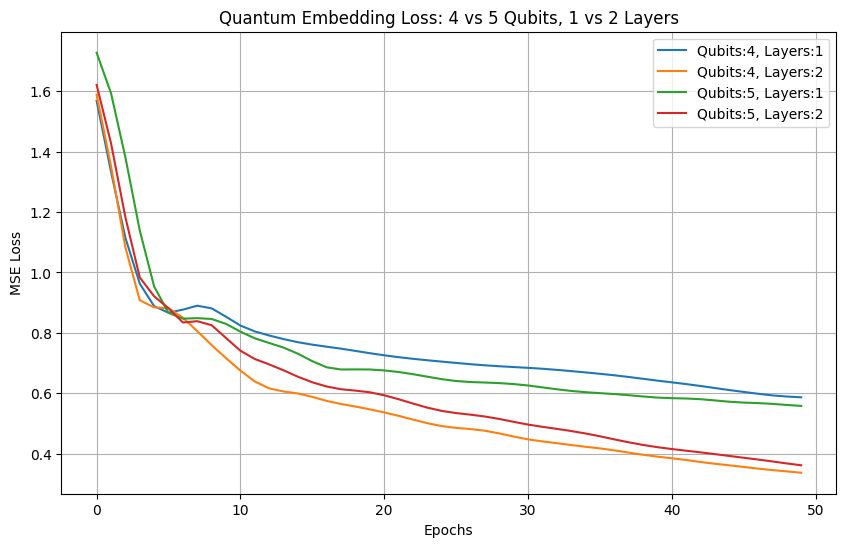

Configuration        | Final MSE Loss 
----------------------------------------
Qubits:4, Layers:1   | 0.586509
Qubits:4, Layers:2   | 0.336580
Qubits:5, Layers:1   | 0.557916
Qubits:5, Layers:2   | 0.361182


In [7]:
plt.figure(figsize=(10, 6))

for config in configs:
    n_q, n_l = config["q"], config["l"]
    label = f"Qubits:{n_q}, Layers:{n_l}"
    print(f"--- Training {label} ---")

    model = HybridModel(n_qubits=n_q, n_layers=n_l)
    optimizer = optim.Adam(model.parameters(), lr=0.02)
    loss_fn = nn.MSELoss()

    history = []
    for epoch in range(50):
        optimizer.zero_grad()
        predictions = model(X)
        loss = loss_fn(predictions, X)
        loss.backward()
        optimizer.step()
        history.append(loss.item())

    all_histories[label] = history
    final_results.append((label, history[-1]))
    plt.plot(history, label=label)

    # Draw the circuit for this configuration
    print(f"Circuit Diagram for {label}:")
    # Sample weights for visualization
    sample_p = torch.zeros(model.output_dim)
    print(qml.draw(model.quantum_circuit)(sample_p))
    print("\n")

# 4. Final Visualization
plt.title("Quantum Embedding Loss: 4 vs 5 Qubits, 1 vs 2 Layers")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.show()

# Print Table Summary
print(f"{'Configuration':<20} | {'Final MSE Loss':<15}")
print("-" * 40)
for label, loss in final_results:
    print(f"{label:<20} | {loss:.6f}")